# HITS

**Instrucciones de la actividad**

Revisa el siguiente cuaderno de trabajo y realiza las actividades:





HITS.ipynb




El cuaderno de trabajo utiliza la siguiente red:



ca-netscience.mtx




Además, encuentra los vértices de mayor centralidad de la mini red:

Usando la centralidad de hubs
Usando la centralidad de autoridad
Elige una base de datos (la misma que usaste en la actividad de centralidad de grado y de eigenvector) y encuentra los vértices de mayor centralidad, usando centralidades de hubs y autoridad.



En ambas redes, realiza un análisis: ¿qué se puede decir de los vértices de mayor centralidad? ¿Tiene sentido? ¿Qué se puede decir de la centralidad de sus vecinos (a los que apunta y los que lo apuntan)? ¿En qué cambian? ¿Cómo se comparan con los vértices obtenidos en la actividad de centralidad de grado, de eigenvector, de Katz y PageRank? Para los vértices que bajan o suben de centralidad, ¿qué se puede decir de sus vecinos (a los que apunta y los que lo apuntan)?



En ambas redes realizar cuatro visualizaciones personalizando el tamaño y color de cada nodo de acuerdo a su centralidad, respecto a centralidad de hubs y  respecto a centralidad de autoridad.

Cargamos las librerías:

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Ejemplo 1

In [2]:
stark_targaryen = ['Rickard','Lyarra','Aerys','Rhaella','Catelyn','Ned','Lyanna','Rhaegar','Elia','Viserys','Daenerys',
                   'Brandon', 'Benjen', 'Robb', 'Sansa', 'Arya', 'Bran', 'Rickon', 'Rhaenys', 'Aegon','Jon']

parents = [('Rickard','Ned'),('Rickard','Lyanna'),('Rickard','Brandon'),('Rickard','Benjen'),
           ('Lyarra','Ned'),('Lyarra','Lyanna'),('Lyarra','Brandon'),('Lyarra','Benjen'),
           ('Aerys','Rhaegar'),('Aerys','Viserys'),('Aerys','Daenerys'),
           ('Rhaella','Rhaegar'),('Rhaella','Viserys'),('Rhaella','Daenerys'),
           ('Catelyn','Robb'),('Catelyn','Sansa'), ('Catelyn','Arya'), ('Catelyn','Bran'), ('Catelyn','Rickon'),
           ('Ned','Robb'),('Ned','Sansa'), ('Ned','Arya'), ('Ned','Bran'), ('Ned','Rickon'),
           ('Rhaegar','Rhaenys'), ('Rhaegar','Aegon'),('Elia','Rhaenys'), ('Elia','Aegon'),
           ('Lyanna','Jon'),('Rhaegar','Jon')]

Vamos a considerar la red dirigida:

In [3]:
G=nx.DiGraph()

In [4]:
G.add_nodes_from(stark_targaryen)
G.add_edges_from(parents)

layout=nx.kamada_kawai_layout(G)
#nx.draw(G,layout, with_labels=True)

Podemos usar la función "hits": 

https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.link_analysis.hits_alg.hits.html#networkx.algorithms.link_analysis.hits_alg.hits

Ahora vamos a calcular las centralidades de autoridad y concentrador de los nodos. Nos da un diccionario con cada una de las centralidades, las cuales están normalizadas.

In [5]:
hubs_centralities, auth_centralities = nx.hits(G)

Podemos ordenar las centralidades de concentrador y de autoridad:

In [6]:
dict(sorted(hubs_centralities.items(), key=lambda item:item[1], reverse=True))

{'Catelyn': 0.5000000000000003,
 'Ned': 0.5000000000000003,
 'Elia': 1.8867456553252696e-17,
 'Aerys': 1.360337039657823e-17,
 'Rhaella': 1.360337039657823e-17,
 'Viserys': 0.0,
 'Daenerys': 0.0,
 'Brandon': 0.0,
 'Benjen': 0.0,
 'Robb': 0.0,
 'Sansa': 0.0,
 'Arya': 0.0,
 'Bran': 0.0,
 'Rickon': 0.0,
 'Rhaenys': 0.0,
 'Aegon': 0.0,
 'Jon': 0.0,
 'Rhaegar': -1.8000984744279026e-17,
 'Lyanna': -3.686844129753172e-17,
 'Rickard': -3.489138138771663e-16,
 'Lyarra': -3.489138138771663e-16}

In [7]:
dict(sorted(auth_centralities.items(), key=lambda item:item[1], reverse=True))

{'Robb': 0.20000000000000018,
 'Sansa': 0.20000000000000018,
 'Arya': 0.20000000000000018,
 'Bran': 0.20000000000000018,
 'Rickon': 0.20000000000000018,
 'Rhaenys': 1.88674565532527e-17,
 'Aegon': 1.88674565532527e-17,
 'Rhaegar': 9.068913597718823e-18,
 'Viserys': 9.068913597718823e-18,
 'Daenerys': 9.068913597718823e-18,
 'Rickard': 0.0,
 'Lyarra': 0.0,
 'Aerys': 0.0,
 'Rhaella': 0.0,
 'Catelyn': 0.0,
 'Elia': 0.0,
 'Jon': -7.373688259506346e-17,
 'Ned': -1.7445690693858317e-16,
 'Lyanna': -1.7445690693858317e-16,
 'Brandon': -1.7445690693858317e-16,
 'Benjen': -1.7445690693858317e-16}

Podemos ver que Catelyn y Ned tienen la mayor centralidad de concentrador y disminuye sustancialmente su centralidad de autoridad. Los que tienen mayor centralidad de autoridad don Robb, Sansa, Arya, Bran y Rickon.

### Actividad

Responde: ¿Tienen sentido estos resultados en la red? Justifica.

Puedes ayudarte de una mejor visualización de la red para responder:

c:\Users\herie\miniconda3\envs\a\Lib\site-packages\matplotlib\collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
c:\Users\herie\miniconda3\envs\a\Lib\site-packages\networkx\drawing\nx_pylab.py:1688: RuntimeWarning: invalid value encountered in sqrt
  return self.np.sqrt(marker_size) / 2


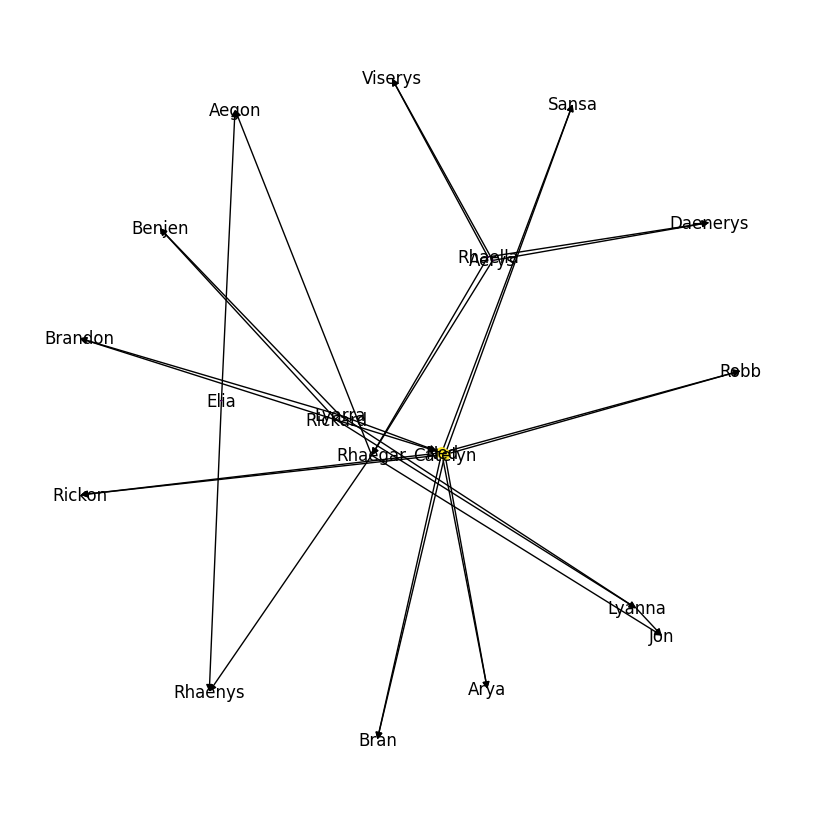

In [8]:
hubs_lista = [hubs_centralities[i] for i in G]

hubs_sizes = np.array(hubs_lista)

hubs_colors = np.array([hubs_centralities[i] for i in G])

plt.figure(figsize = [8,8] )

nx.draw(G, with_labels=True,node_size = 100*hubs_sizes, node_color = hubs_colors, cmap = 'viridis')

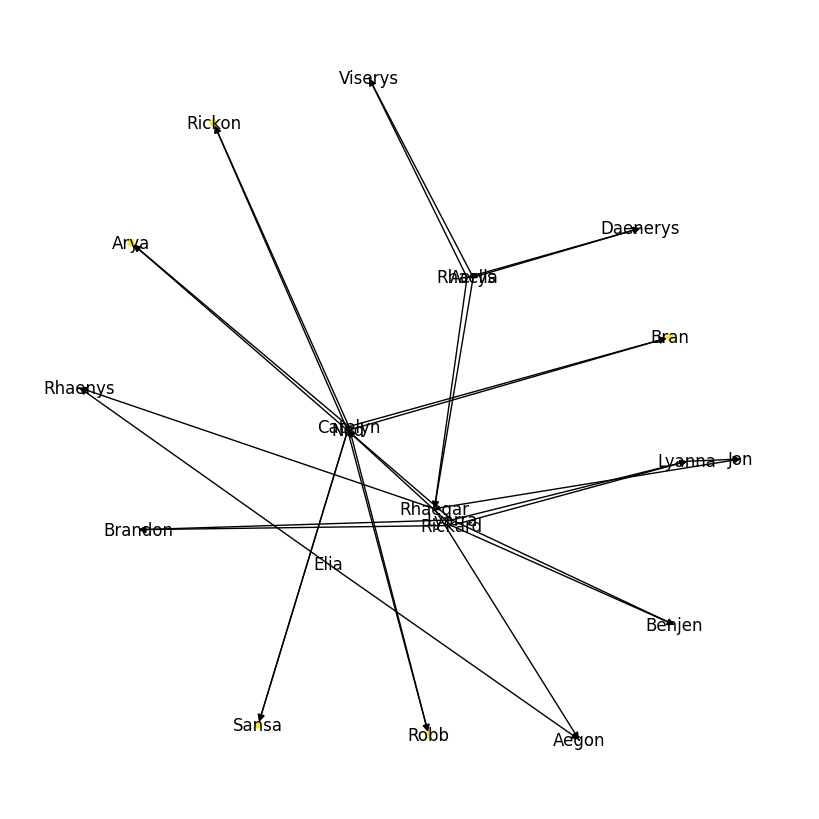

In [9]:
auth_lista = [auth_centralities[i] for i in G]

auth_sizes = np.array(auth_lista)

auth_colors = np.array([auth_centralities[i] for i in G])

plt.figure(figsize = [8,8] )

nx.draw(G, with_labels=True,node_size = 100*auth_sizes, node_color = auth_colors, cmap = 'viridis')

Si buscamos la centralidad de eigenvector:

In [10]:
eig_centralidades=nx.eigenvector_centrality(G,max_iter=1000, tol=1e-06)
dict(sorted(eig_centralidades.items(), key=lambda item:item[1], reverse=True))

{'Jon': 0.602262756575024,
 'Robb': 0.30172591036977997,
 'Sansa': 0.30172591036977997,
 'Arya': 0.30172591036977997,
 'Bran': 0.30172591036977997,
 'Rickon': 0.30172591036977997,
 'Rhaenys': 0.3017259103697799,
 'Aegon': 0.3017259103697799,
 'Ned': 0.0011890641645357198,
 'Lyanna': 0.0011890641645357198,
 'Rhaegar': 0.0011890641645357198,
 'Viserys': 0.0011890641645357198,
 'Daenerys': 0.0011890641645357198,
 'Brandon': 0.0011890641645357198,
 'Benjen': 0.0011890641645357198,
 'Rickard': 1.1714917877199222e-06,
 'Lyarra': 1.1714917877199222e-06,
 'Aerys': 1.1714917877199222e-06,
 'Rhaella': 1.1714917877199222e-06,
 'Catelyn': 1.1714917877199222e-06,
 'Elia': 1.1714917877199222e-06}

### Actividad

Responde: ¿hay similitud con los resultados de la centralidad de hubs o de autoridad? ¿A qué crees que se deba?

## Ejemplo 2

Utilicemos la red de colaboración científica.

In [11]:
datos = pd.read_csv('data/ca-netscience.mtx', skiprows = 2, header = None,sep = ' ')

aristas = datos[[0,1]].values
G1 = nx.Graph()
G1.add_edges_from(aristas)

Obtengamos las centralidades de hubs y de autoridad de los nodos.

In [12]:
hubs_centralities_CA, auth_centralities_CA = nx.hits(G1)

In [13]:
dict(sorted(hubs_centralities_CA.items(), key=lambda item:item[1], reverse=True))

{np.int64(4): 0.06684460891071262,
 np.int64(5): 0.057471812421975445,
 np.int64(16): 0.05589759633823402,
 np.int64(15): 0.04126252016496161,
 np.int64(45): 0.03823112640771413,
 np.int64(46): 0.03521240877772527,
 np.int64(47): 0.03521240877772527,
 np.int64(176): 0.03521240877772527,
 np.int64(177): 0.03521240877772527,
 np.int64(250): 0.023725643670804472,
 np.int64(1): 0.022445417273402317,
 np.int64(313): 0.02175249972987188,
 np.int64(314): 0.021752499729871873,
 np.int64(13): 0.019519079038282178,
 np.int64(373): 0.018697767041349476,
 np.int64(14): 0.017688259476167086,
 np.int64(249): 0.017369257984384517,
 np.int64(323): 0.01716964875954542,
 np.int64(324): 0.01716964875954542,
 np.int64(44): 0.014287340600621899,
 np.int64(374): 0.013783890761660932,
 np.int64(154): 0.013091861430757957,
 np.int64(153): 0.013091861430757955,
 np.int64(201): 0.012151491857404878,
 np.int64(371): 0.011830051047606285,
 np.int64(231): 0.010574425568090205,
 np.int64(128): 0.009980475719827478,

In [14]:
dict(sorted(auth_centralities_CA.items(), key=lambda item:item[1], reverse=True))

{np.int64(4): 0.0668446089107126,
 np.int64(5): 0.057471812421975466,
 np.int64(16): 0.05589759633823402,
 np.int64(15): 0.04126252016496157,
 np.int64(45): 0.03823112640771414,
 np.int64(176): 0.035212408777725274,
 np.int64(47): 0.03521240877772526,
 np.int64(177): 0.03521240877772526,
 np.int64(46): 0.035212408777725246,
 np.int64(250): 0.023725643670804483,
 np.int64(1): 0.0224454172734023,
 np.int64(314): 0.02175249972987188,
 np.int64(313): 0.021752499729871845,
 np.int64(13): 0.01951907903828218,
 np.int64(373): 0.01869776704134948,
 np.int64(14): 0.017688259476167093,
 np.int64(249): 0.017369257984384507,
 np.int64(324): 0.017169648759545426,
 np.int64(323): 0.017169648759545415,
 np.int64(44): 0.014287340600621899,
 np.int64(374): 0.013783890761660922,
 np.int64(153): 0.013091861430757962,
 np.int64(154): 0.013091861430757953,
 np.int64(201): 0.012151491857404884,
 np.int64(371): 0.011830051047606285,
 np.int64(231): 0.010574425568090207,
 np.int64(128): 0.009980475719827483,


### Actividad

Responde, ¿hay cambios sustanciales de los nodos en sus distintos roles (de autoridad y de concentrador)? ¿O están rankeados similarmente en ambos roles? ¿Hay nodos que tengan una diferencia de al menos 10 lugares en su ranking como autoridad y como concentrador? ¿Cuál es el mayor diferencia? ¿A qué crees que se deba?

¿Hay cambios sustanciales con respecto a la centralidad de eigenvector?

También podemos visualizar. ¿Se pueden mejorar las visualizaciones?

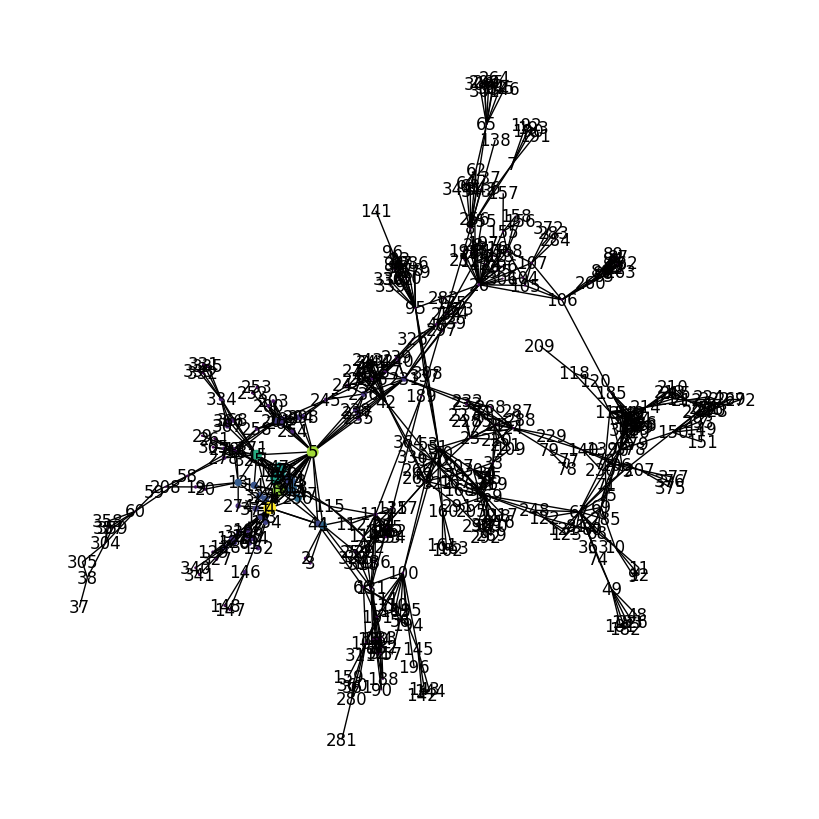

In [15]:
hubs_lista_CA = [hubs_centralities_CA[i] for i in G1]

hubs_sizes_CA = np.array(hubs_lista_CA)

hubs_colors_CA = np.array([hubs_centralities_CA[i] for i in G1])

plt.figure(figsize = [8,8] )

nx.draw(G1, with_labels=True,node_size = 1000*hubs_sizes_CA, node_color = hubs_colors_CA, cmap = 'viridis')

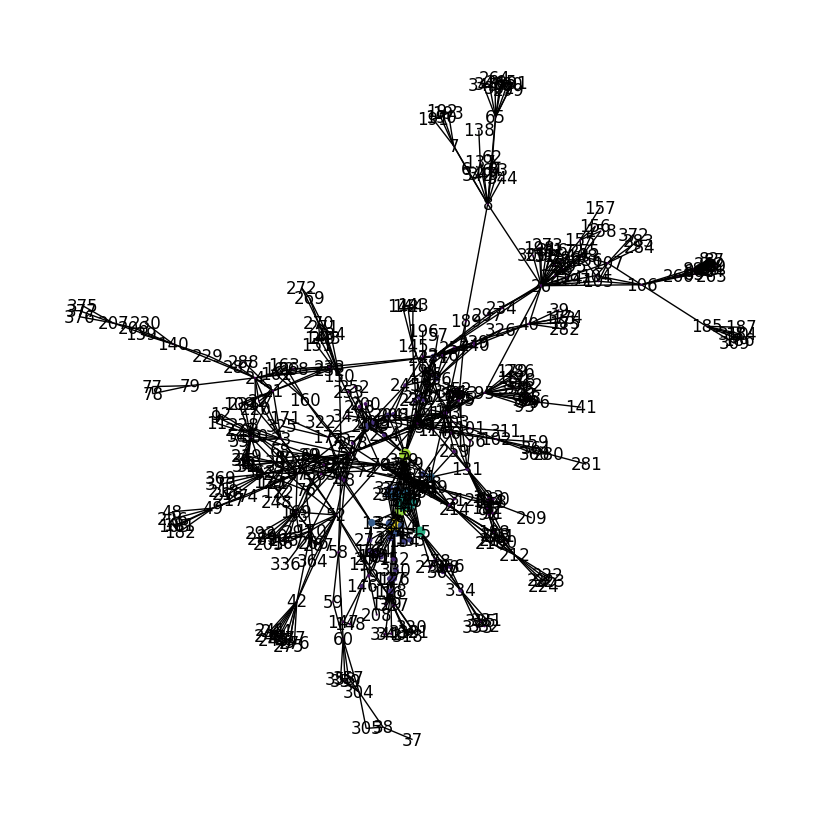

In [16]:
auth_lista_CA = [auth_centralities_CA[i] for i in G1]

auth_sizes_CA = np.array(auth_lista_CA)

auth_colors_CA = np.array([auth_centralities_CA[i] for i in G1])

plt.figure(figsize = [8,8] )

nx.draw(G1, with_labels=True,node_size = 1000*auth_sizes_CA, node_color = auth_colors_CA, cmap = 'viridis')